# Linear Regression and Feature Engineering

This project develops linear regression from a simple synthetic relationship to nonlinear feature expansion and a real regression dataset. The focus is on model fitting, prediction error, interpretation of learned coefficients, and the effect of adding nonlinear features.

## Technical Scope

- Linear regression with scikit-learn
- Train/test evaluation
- Mean squared error and mean absolute error
- Coefficient and intercept interpretation
- Linear-model limitations on nonlinear relationships
- Polynomial feature expansion
- California Housing regression
- Prediction clipping and quadratic features

## Running in Google Colab

The particle data are stored in the repository under `data/`. When this notebook is opened directly from GitHub in Google Colab, Colab loads the notebook but not the complete repository.

Run the setup cell below once in Colab. It clones the full repository and moves the working directory to this notebook folder, allowing the existing relative data paths such as `../data/particles_X.npy` to work without changing the analysis code.

When the repository has already been cloned locally and the notebook is run from its `notebooks/` folder, this setup cell does nothing.

In [3]:
# Repository setup for Google Colab
from pathlib import Path
import os
import subprocess

particle_file = Path("../data/particles_X.npy")

if not particle_file.exists():
    try:
        import google.colab  # Runs only in Google Colab

        repo_url = input(
            "Paste the GitHub repository URL "
            "(for example, https://github.com/USERNAME/machine-learning-projects.git): "
        ).strip()

        repo_dir = Path("/content/machine-learning-projects")

        if not repo_dir.exists():
            subprocess.run(
                ["git", "clone", repo_url, str(repo_dir)],
                check=True
            )

        notebook_dir = repo_dir / "02-linear-regression" / "notebooks"
        os.chdir(notebook_dir)
        print("Working directory:", Path.cwd())

    except ImportError:
        print(
            "Particle data were not found. Run this notebook from "
            "02-linear-regression/notebooks or update the working directory."
        )
else:
    print("Repository data found:", particle_file)


Paste the GitHub repository URL (for example, https://github.com/USERNAME/machine-learning-projects.git): https://github.com/smolla-cps/machine-learning-projects.git
Working directory: /content/machine-learning-projects/02-linear-regression/notebooks


## 1. Setup

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


## 2. Recovering a Known Linear Relationship

A synthetic dataset is generated from a known linear relationship with added Gaussian noise:

\[
y = 2X + 1 + \varepsilon
\]

The data are split into training and test sets so that model performance is evaluated on unseen observations.

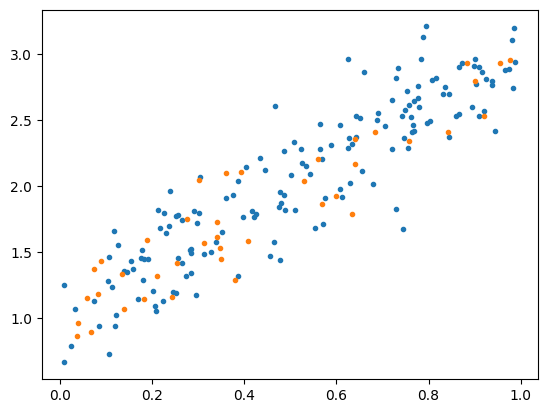

In [5]:
n = 200
X = np.random.random(size=n)
y = 2*X + 1 + np.random.normal(size=n)*.25

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X.reshape(-1,1), y, test_size=0.2, random_state=4361)
plt.figure()
plt.plot(X_train,y_train,'.')
plt.plot(X_test,y_test,'.')

### Model Fitting and Test-Set Evaluation

The model is fitted on the training data and evaluated using mean squared error (MSE) and mean absolute error (MAE).

Mean squared error = 0.051
Mean absolute error =  0.185


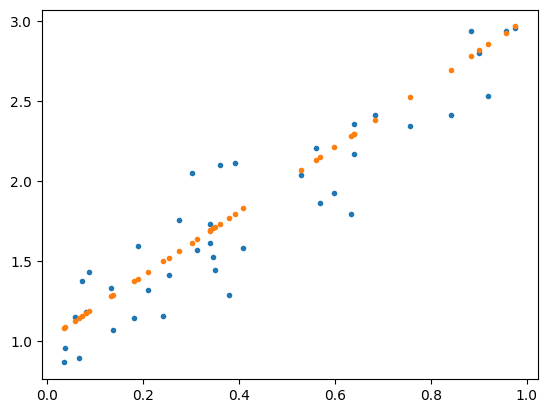

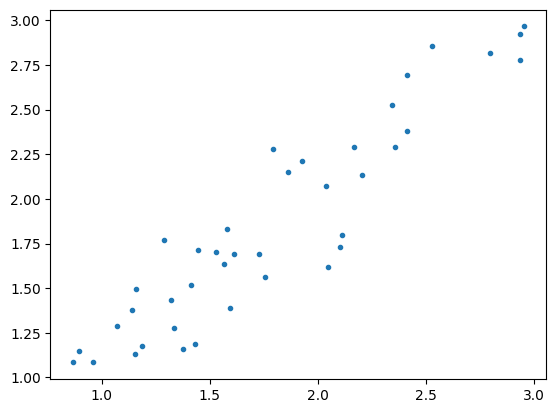

In [6]:
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
plt.figure()
plt.plot(X_test,y_test,'.')
plt.plot(X_test,pred,'.')
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
plt.figure()
plt.plot(y_test,pred,'.')
plt.show()

### Learned Model Parameters

Because the data were generated with slope 2 and intercept 1, the learned coefficient and intercept can be compared directly with the underlying relationship.

In [7]:
print(model.coef_)
print(model.intercept_)

[2.00307193]
1.0112079998394228


### Reconstructing Predictions from the Learned Parameters

The prediction equation can also be evaluated directly from the learned coefficient and intercept.

In [8]:
pred2 = model.coef_[0]*X_test + model.intercept_

In [9]:
print(pred[:10])
print(pred2[:10][:,0])

[1.18905662 1.17657339 2.21000745 2.1338871  2.15190492 1.08686204
 1.15782828 2.85453105 1.70479628 1.43173432]
[1.18905662 1.17657339 2.21000745 2.1338871  2.15190492 1.08686204
 1.15782828 2.85453105 1.70479628 1.43173432]


## 3. Linear Regression on a Nonlinear Relationship

The next dataset follows a quadratic relationship:

\[
y = X^2 - 3X + 10 + \varepsilon
\]

A standard linear model using only \(X\) cannot represent the curvature in this relationship.

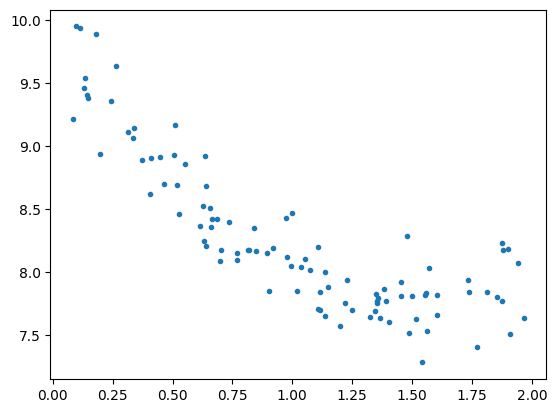

In [10]:
X = np.random.random(size=100)*2
y = X**2 - 3*X + 10 + np.random.normal(size=100)*.25
plt.figure()
plt.plot(X,y,'.')

### Linear Baseline

Mean squared error = 0.11279
Mean absolute error =  0.27322
[-0.97103931]
9.23916217838279


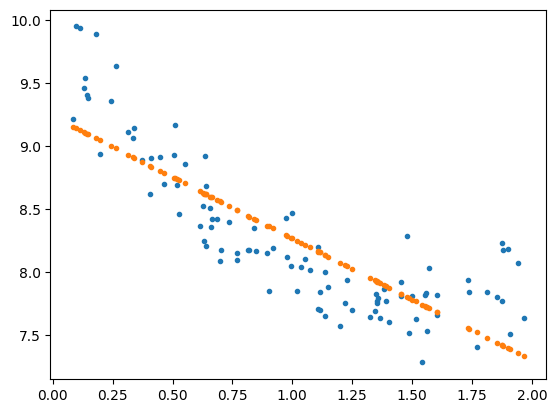

In [11]:
model = LinearRegression()
model.fit(X.reshape(-1,1),y)
pred = model.predict(X.reshape(-1,1))
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y)))
plt.figure()
plt.plot(X,y,'.')
plt.plot(X,pred,'.')
print(model.coef_)
print(model.intercept_)

### Adding a Quadratic Feature

The model remains linear in its learned parameters, but the input representation is expanded to include \(X^2\). This allows linear regression to represent the quadratic structure.

Mean squared error = 0.04613
Mean absolute error =  0.16622
[ 0.94599073 -2.87825679]
9.936185857028624


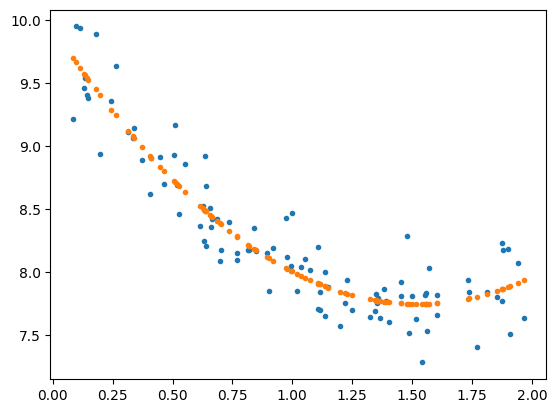

In [12]:
XX = np.zeros((len(X),2))
XX[:,1] = X
XX[:,0] = X**2
model = LinearRegression()
model.fit(XX,y)
pred = model.predict(XX)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y)))
plt.figure()
plt.plot(X,y,'.')
plt.plot(X,pred,'.')
print(model.coef_)
print(model.intercept_)

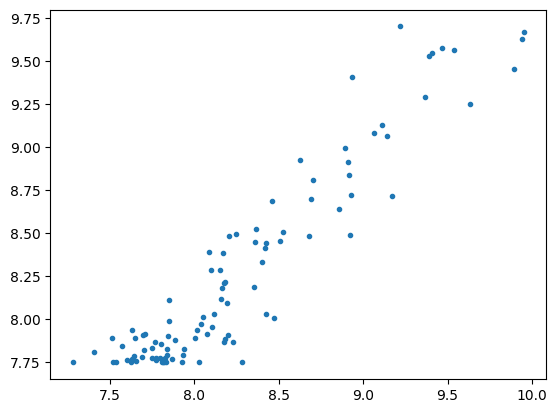

In [13]:
plt.figure()
plt.plot(y,pred,'.')
plt.show()

## 4. California Housing Regression

The California Housing dataset provides a multivariable regression problem. A baseline linear model is trained using the original features and evaluated on a held-out test set.

In [14]:
from sklearn.datasets import fetch_california_housing
dataset = fetch_california_housing()
x = dataset.data
y = dataset.target
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=5361)

model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))

print(model.coef_)
print(model.intercept_)

Mean squared error = 0.54565
Mean absolute error =  0.54147
[ 4.47022152e-01  9.31480965e-03 -1.26107922e-01  6.74080266e-01
 -4.27214102e-06 -3.94060963e-03 -4.14203716e-01 -4.28602827e-01]
-36.45487156115954


### Predicted versus Observed Values

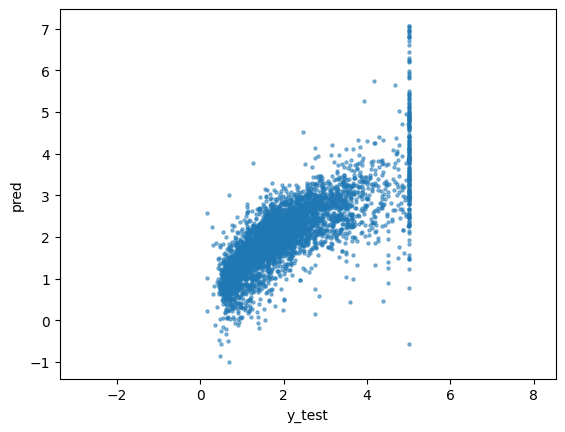

In [15]:
plt.scatter(y_test,pred,s=5,alpha=0.5)
plt.xlabel("y_test")
plt.ylabel("pred")
plt.axis('equal')
plt.show()

### Constraining Predictions to the Training Target Range

Predictions are clipped to the minimum and maximum target values observed in the training data, then reevaluated.

Mean squared error = 0.52512
Mean absolute error =  0.52926


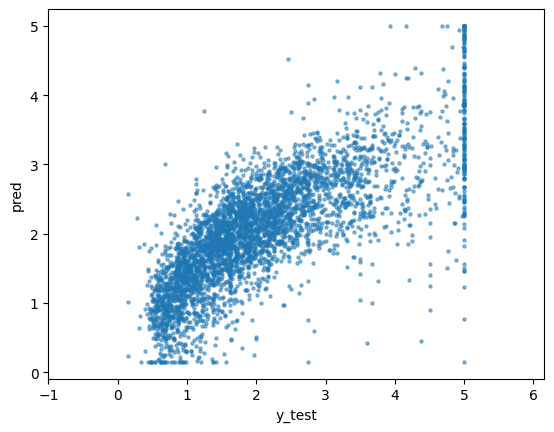

In [16]:
pred = model.predict(X_test)
pred = np.clip(pred, np.min(y_train),np.max(y_train))
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))

plt.scatter(y_test,pred,s=5,alpha=0.5)
plt.xlabel("y_test")
plt.ylabel("pred")
plt.axis('equal')
plt.show()

### Extending the Housing Features

Each original feature is supplemented with its squared value. This tests whether a simple nonlinear expansion improves predictive performance while retaining a linear regression model.

Mean squared error = 0.50562
Mean absolute error =  0.52336


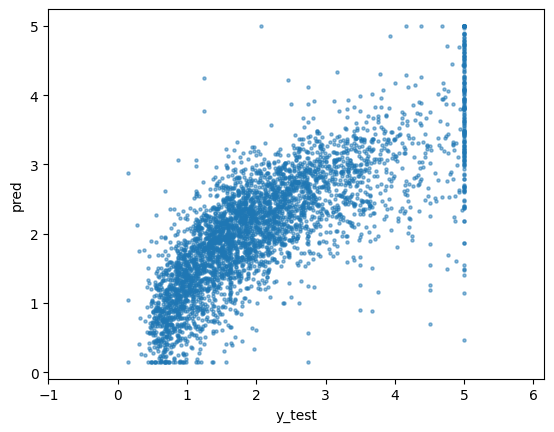

In [17]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=5361)

X_train = np.hstack((X_train,X_train**2))
X_test = np.hstack((X_test,X_test**2))
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
pred = np.clip(pred, np.min(y_train),np.max(y_train))
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))

plt.scatter(y_test,pred,s=5,alpha=0.5)
plt.xlabel("y_test")
plt.ylabel("pred")
plt.axis('equal')
plt.show()



## 5. Results Summary

| Experiment | MSE | MAE |
|---|---:|---:|
| Synthetic linear relationship | 0.048 | 0.172 |
| Quadratic data with only the original feature | 0.12208 | 0.26652 |
| Quadratic data with \(X^2\) added | 0.04786 | 0.17521 |
| California Housing baseline | 0.54565 | 0.54147 |
| California Housing with clipped predictions | 0.52512 | 0.52926 |
| California Housing with squared features | 0.50562 | 0.52336 |

Adding the correct nonlinear representation substantially improves the quadratic example. On the California Housing dataset, clipping and squared-feature expansion also reduce the reported error relative to the baseline.

## 6. Technical Takeaways

- Linear regression can recover the parameters of an approximately linear relationship.
- Training and test data should be separated when estimating generalization performance.
- A linear model cannot capture nonlinear structure unless that structure is represented in the features.
- Polynomial feature expansion can increase model flexibility without changing the underlying linear estimator.
- MSE and MAE provide complementary views of regression error.